r vectors projected to ellipsoid


/tmp/ipykernel_725367/1528186336.py:145: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-x" (-> marker='x'). The keyword argument will take precedence.
  ax2.loglog(n_points_in, acc_rmse, '-x', label=grid_name, color=cols[i], marker=markers[i], markersize=3)
/tmp/ipykernel_725367/1528186336.py:46: RuntimeWarning: divide by zero encountered in divide
  lambda x:180*360/((x*N_points_f)**2)))


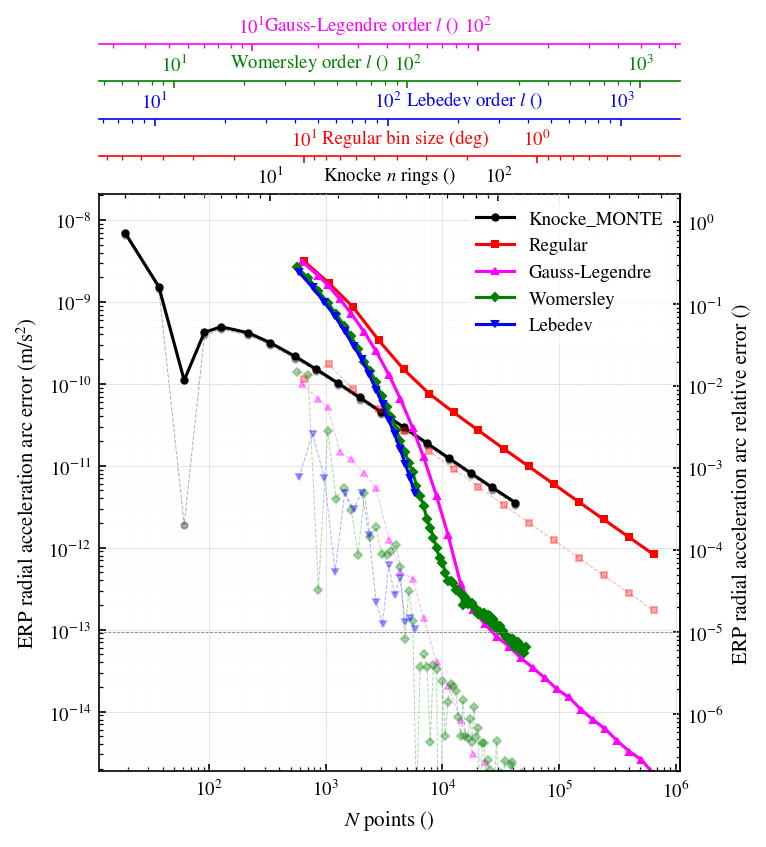

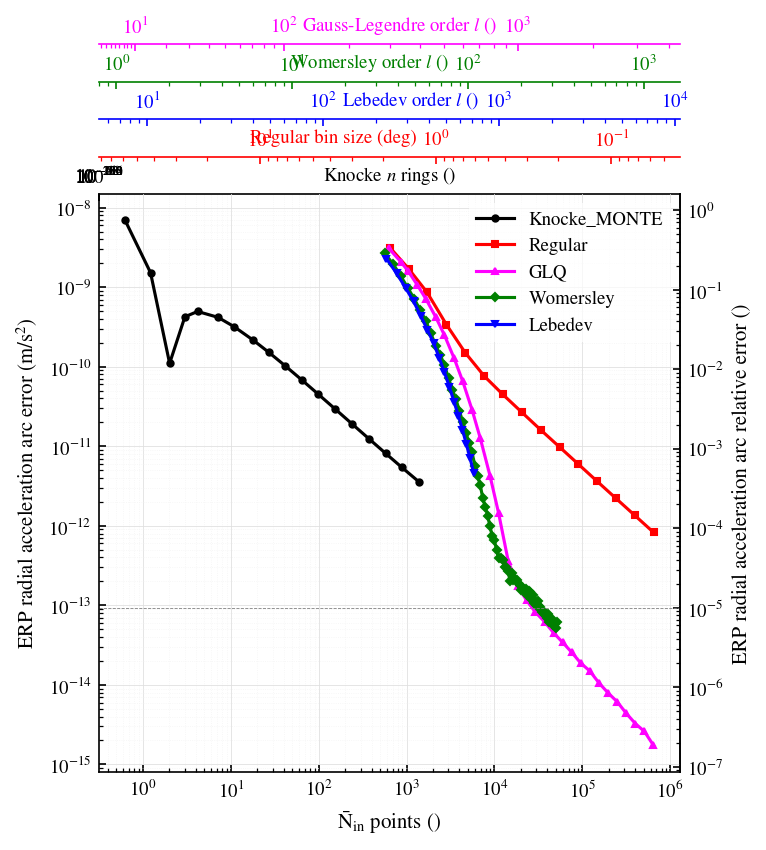

In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from SpaceBalls.paths import OUTPUT_DIR, MEDIA_DIR
from SpaceBalls.plotter import Plotter
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor
import SpaceBalls.input_database_manager as input_manager
import config.constants as constants
Re = constants.earth_radius()
markers = ['o', 's', '^', 'D', 'v']
colors = ['k', 'red', 'magenta', 'green', 'blue']
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c','#d62728', '#9467bd']

cols = colors.copy()

def format_axes(ax: Axes, mag_true, N_points_f=1, mag="acceleration"): # N_points_f to convert from plotted to actual in non-ring grids

    units = 'm/s$^2$' if mag=="acceleration" else "W/m$^2$"
    ax.legend()
    ax.set_ylabel('ERP radial ' + mag + ' arc error ('+ units +')')
    ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)

    ax_right = ax.secondary_yaxis('right', functions=(lambda x: x/mag_true, 
                                                      lambda x: x*mag_true))
    
    ax_right.set_ylabel('ERP radial ' + mag + ' arc relative error ()')
    ax.axhline(1e-5*mag_true, color='gray', lw=0.4, linestyle='--')
    # ax_right.spines['right'].set_visible(True)
    # ax_right.yaxis.set_ticks_position('right')
    # ax_right.yaxis.set_label_position('right')
    # ax_right.tick_params(axis='y', colors='black', direction='in')

    #if add_monte_convergence:
    col_idx = 0 #grid_names.index('MONTE')
    ax_top_0 = ax.secondary_xaxis('top', functions=(lambda x:-0.5 + 0.5*np.sqrt((4*x - 1)/3), 
                                                    lambda x: 1+3*x*(1+x)))
    ax_top_0.set_xlabel('Knocke $n$ rings ()', fontsize=9, labelpad=-7, color=cols[col_idx])
    ax_top_0.spines['top'].set_color(cols[col_idx])
    ax_top_0.tick_params(axis='x', colors=cols[col_idx], which='both')
    

    col_idx = grid_names.index('Regular')
    ax_top_3 = ax.secondary_xaxis('top', functions=(lambda x:np.sqrt(180*360/(x/N_points_f)), 
                                                    lambda x:180*360/((x*N_points_f)**2)))
    ax_top_3.set_xlabel('Regular bin size (deg)', color=cols[col_idx], fontsize=9, labelpad=-7)
    ax_top_3.spines['top'].set_color(cols[col_idx])
    ax_top_3.tick_params(axis='x', colors=cols[col_idx], which='both')
    ax_top_3.spines['top'].set_position(('outward', 18))

    col_idx = grid_names.index('Lebedev')
    ax_top_1 = ax.secondary_xaxis('top', functions=(lambda x:((x/N_points_f)/0.34)**0.5, 
                                                    lambda x: 0.34*(x*N_points_f)**2)) #
    ax_top_1.set_xlabel('Lebedev order $l$ ()', color=cols[col_idx], fontsize=9, labelpad=-7)
    ax_top_1.spines['top'].set_color(cols[col_idx])
    ax_top_1.tick_params(axis='x', colors=cols[col_idx], which='both')
    ax_top_1.spines['top'].set_position(('outward', 36))

    col_idx = grid_names.index('Womersley')
    ax_top_2 = ax.secondary_xaxis('top', functions=(lambda x:(x/0.5)**0.5, lambda x: 0.5*x**2))
    ax_top_2.set_xlabel('Womersley order $l$ ()', color=cols[col_idx], fontsize=9, labelpad=-7)
    ax_top_2.spines['top'].set_color(cols[col_idx])
    ax_top_2.tick_params(axis='x', colors=cols[col_idx], which='both')
    ax_top_2.spines['top'].set_position(('outward', 54))

    # 0.25 * (-3 + np.sqrt(1 + 8*(x/N_points_f)))
    col_idx = grid_names.index('GLQ')
    ax_top_4 = ax.secondary_xaxis('top', functions=(lambda x: 0.25 * (-3 + np.sqrt(1 + 8*(x/N_points_f))), 
                                                    lambda x: 2*(x*N_points_f)**2 + 3*(x*N_points_f) + 1)) #
    ax_top_4.set_xlabel('Gauss-Legendre order $l$ ()', color=cols[col_idx], fontsize=9, labelpad=-7)
    ax_top_4.spines['top'].set_color(cols[col_idx])
    ax_top_4.tick_params(axis='x', colors=cols[col_idx], which='both')
    ax_top_4.spines['top'].set_position(('outward', 72))


    Plotter.add_grid(ax, show_minor=True)

    Plotter.adjust_label_to_avoid_ticklabels(ax_top_0)
    Plotter.adjust_label_to_avoid_ticklabels(ax_top_1)
    Plotter.adjust_label_to_avoid_ticklabels(ax_top_2)
    Plotter.adjust_label_to_avoid_ticklabels(ax_top_3)
    Plotter.adjust_label_to_avoid_ticklabels(ax_top_4)


    #if not(add_monte_convergence):
        # ax_top_2 = ax.secondary_xaxis('top', functions=(lambda x:(x/0.5)**0.5, lambda x: 0.5*x**2))
        # ax_top_2.set_xlabel('Womersley order $n$ ()', color='green') #, fontsize=9, labelpad=-2)
        # ax_top_2.spines['top'].set_color('green')
        # ax_top_2.tick_params(axis='x', colors='green', which='both')
        # ax_top_2.spines['top'].set_position(('outward', 17))




base_sb_tag = 'GRACE-FO_spherical' # 'GRACE-FO_spherical'  # 'Ajisai' #  ##'SB_R800_0'
EEI_truth_name = "EEI_truth_15"
add_monte_convergence = False
n_days_arc = 1

baseline_sb_name = base_sb_tag + '_119' if ((base_sb_tag == 'LAGEOS') or (base_sb_tag == 'Ajisai')) else base_sb_tag #add_monte_convergence else base_sb_tag
flux_to_acc = -1/get_acc_to_flux_factor(baseline_sb_name)
orbit_sma = input_manager.get_dicts(baseline_sb_name)['orbit']['a_0']
N_to_Nin_f = 0.5 * (orbit_sma - Re) / orbit_sma

base_dir = os.path.join(MEDIA_DIR, 'convergence_analysis', base_sb_tag, EEI_truth_name)
true_erp_Fr_series = np.concatenate([np.load(os.path.join(base_dir,'day_'+str(i), 'true_erp_Fr.npy')) for i in range(n_days_arc)])
mag_true_erp_acc_r = np.abs(np.mean(true_erp_Fr_series) * flux_to_acc)
mag_true_erp_flux_r = np.abs(np.mean(true_erp_Fr_series))

grid_names = ['Knocke_MONTE', 'Regular', 'GLQ', 'Womersley', 'Lebedev']
#grid_names = ['Regular', 'GLQ', 'Womersley', 'Lebedev']
#grid_names = ['MONTE', 'Regular', 'Womersley', 'Lebedev']

if not(add_monte_convergence):
    pass
    #grid_names.pop(0)
    #cols.pop(0)
    #markers.pop(0)


fig, ax = plt.subplots(figsize=(5,5))
fig2, ax2 = plt.subplots(figsize=(5,5))
#fig3, ax3 = plt.subplots(figsize=(5,5))

for i, grid_name in enumerate(grid_names):
    errors_fname_last_day = os.path.join(base_dir,'day_'+str(n_days_arc-1), 'errors_Fr_'+grid_name.lower()+'_grids.npy')
    
    if os.path.exists(errors_fname_last_day):
        flux_errors = np.hstack([np.load(os.path.join(base_dir,'day_'+str(i), 'errors_Fr_'+grid_name.lower()+'_grids.npy')) 
                                 for i in range(n_days_arc)])
        #jd_vec = np.hstack([np.load(os.path.join(base_dir,'day_'+str(i), 'jd_vec.npy')) 
        #                         for i in range(n_days_arc)])
        flux_errors_rms = np.sqrt(np.mean(flux_errors**2, axis=1)) # np.max(flux_errors, axis=1) # 
        flux_errors_bias = np.abs(np.mean(flux_errors, axis=1))
        acc_rmse = flux_errors_rms * flux_to_acc
        acc_bias = flux_errors_bias * flux_to_acc
        n_points = np.load(os.path.join(base_dir, 'n_points_'+grid_name.lower()+'_grids.npy'))

        label = 'Gauss-Legendre' if grid_name=="GLQ" else grid_name
        ax.loglog(n_points, acc_rmse, '-', label=label, color=cols[i], marker=markers[i], markersize=3)
        ax.loglog(n_points, acc_bias, '--', alpha=0.3, color=cols[i], lw=0.5, marker=markers[i], markersize=3)
        
        n_points_in = n_points * N_to_Nin_f if ("MONTE" in grid_name) else n_points
        ax2.loglog(n_points_in, acc_rmse, '-x', label=grid_name, color=cols[i], marker=markers[i], markersize=3)

        #ax3.loglog(n_points, flux_errors_rms, '-x', label=grid_name, color=cols[i])

ax.set_xlabel('$N$ points ()') #, labelpad=-10)
#Plotter.adjust_label_to_avoid_ticklabels(ax)
#ax_d = ax.secondary_xaxis('bottom', functions=(lambda x: 4*Re/np.sqrt(x), 
#                                               lambda x: (4*Re/x)**2))
#ax_d.set_xlabel('Average point separation $d$ (km)', fontsize=9, labelpad=-10)
#ax_d.spines['bottom'].set_position(('outward', 18))
#Plotter.adjust_label_to_avoid_ticklabels(ax_d)

ax.set_ylim(bottom=2e-7*mag_true_erp_acc_r)

if add_monte_convergence:
    pass
    # ax.set_xlim(left=1e2)

format_axes(ax, mag_true=mag_true_erp_acc_r)

#ax3.set_xlabel('N points ()')
#format_axes(ax3, mag="flux", mag_true=mag_true_erp_flux_r)

ax2.set_xlabel(r'$\mathrm{\bar N_{in}}$ points ()')
format_axes(ax2, mag_true=mag_true_erp_acc_r, N_points_f=N_to_Nin_f)

(np.float64(-0.75),
 np.float64(0.75),
 np.float64(-0.75),
 np.float64(0.75),
 np.float64(-0.75),
 np.float64(0.75))

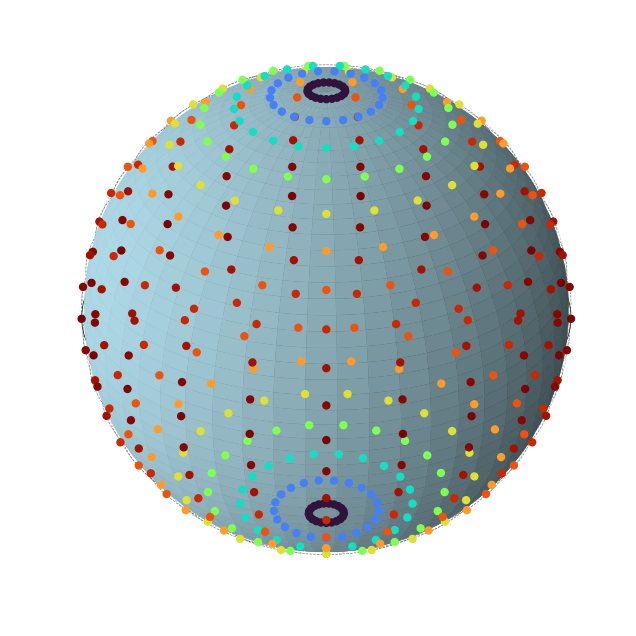

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from config.constants import earth_radius
RE = earth_radius()

def add_gray_sphere(ax):
    # Generate sphere coordinates
    u = np.linspace(0, 2 * np.pi, 5000)
    v = np.linspace(0, np.pi, 5000)
    f = 0.99
    x = np.outer(np.cos(u), np.sin(v))*f
    y = np.outer(np.sin(u), np.sin(v))*f
    z = np.outer(np.ones(np.size(u)), np.cos(v))*f

    # Plot with alpha (transparency) and edgecolors for better mesh visibility
    ax.plot_surface(x, y, z,  color='lightblue', 
                    alpha=1, edgecolor='none')

def add_equator_and_poles(ax):
    eq_theta = np.linspace(0, 2 * np.pi, 100)
    eq_x = np.cos(eq_theta)
    eq_y = np.sin(eq_theta)
    eq_z = np.zeros_like(eq_theta)

    ax.plot(eq_x, eq_y, eq_z, color="k", linestyle="-", linewidth=0.5, alpha=1, zorder=2)
    
    # Hint 2: Plot Poles (North:, South: [0,0,-1])
    ax.scatter([0, 0], [0, 0], [1, -1], color="black", marker="x", s=40, linewidths=1.5, zorder=3)

    # Add meridians (lines of longitude)
    n_meridians = 20
    for i in range(n_meridians):
        theta = (i / n_meridians) * 2 * np.pi  # 0 to 2π (full circle)
        meridian_phi = np.linspace(0, np.pi, 100)
        meridian_x = np.sin(meridian_phi) * np.cos(theta)
        meridian_y = np.sin(meridian_phi) * np.sin(theta)
        meridian_z = np.cos(meridian_phi) * np.ones_like(meridian_phi)
        ax.plot(meridian_x, meridian_y, meridian_z, color="gray", linestyle="--", 
                linewidth=0.5, alpha=0.5)
    
    # Add parallels (lines of latitude)
    n_parallels = 20
    for i in range(1, n_parallels + 1):
        phi = (i / (n_parallels + 1)) * np.pi  # evenly spaced between 0 and π
        parallel_theta = np.linspace(0, 2 * np.pi, 100)
        parallel_x = np.sin(phi) * np.cos(parallel_theta)
        parallel_y = np.sin(phi) * np.sin(parallel_theta)
        parallel_z = np.cos(phi) * np.ones_like(parallel_theta)
        ax.plot(parallel_x, parallel_y, parallel_z, color="k", linestyle="--", 
                linewidth=0.5, alpha=0.5)


fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8,8))
add_gray_sphere(ax)
add_equator_and_poles(ax)
ax.set_box_aspect([1,1,1])

#grid = RegularLatLonGrid(alt_km=-RE+1, n_lat=18, n_lon=36)
#grid = QuadratureGrid(alt_km=-RE+1, order=41, default_womersley=False)
#grid = RegularLatLonGrid(alt_km=-RE+1, lmax=17, quad_type='GLQ')
grid = RegularLatLonGrid(alt_km=-RE+1, n_lat=21, n_lon=21)
scatter = ax.scatter(
    grid.stacked_grid_u[:,0], grid.stacked_grid_u[:,1], grid.stacked_grid_u[:,2],
    c=grid.integration_weights,
    cmap="turbo",
    #vmin=vmin,
    #vmax=vmax,
    s=25,
    edgecolor=None,
    alpha=1,
    zorder=0,
    depthshade=True
)
ax.set_xlim([-0.75, 0.75])
ax.set_ylim([-0.75, 0.75])
ax.set_zlim([-0.75, 0.75])

ax.axis("off")

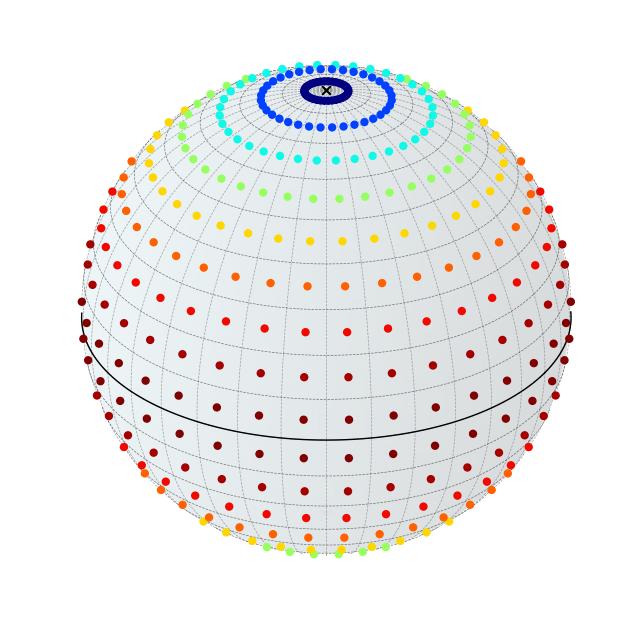

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def add_gray_sphere(ax):
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    f = 0.995  # Keep surface slightly smaller than 1.0 to avoid clipping/Z-fighting
    x = np.outer(np.cos(u), np.sin(v)) * f
    y = np.outer(np.sin(u), np.sin(v)) * f
    z = np.outer(np.ones(np.size(u)), np.cos(v)) * f

    # Explicitly set zorder=1 for the background sphere
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.1, 
                    edgecolor='none', rcount=300, ccount=300, antialiased=True, zorder=1)

def get_camera_vector(elev, azim):
    """Calculates the 3D unit vector pointing from the origin to the camera."""
    e = np.radians(elev)
    a = np.radians(azim)
    return np.array([
        np.cos(e) * np.cos(a),
        np.cos(e) * np.sin(a),
        np.sin(e)
    ])

def filter_front_facing(x, y, z, cam_vec):
    """Masks out coordinates that fall on the back hemisphere relative to the camera."""
    # Dot product: positive values mean the point faces the camera
    dot_product = x * cam_vec[0] + y * cam_vec[1] + z * cam_vec[2]
    
    # Replace hidden points with NaN so Matplotlib breaks the line cleanly
    x_visible = np.where(dot_product >= 0, x, np.nan)
    y_visible = np.where(dot_product >= 0, y, np.nan)
    z_visible = np.where(dot_product >= 0, z, np.nan)
    return x_visible, y_visible, z_visible

def add_equator_and_poles(ax):
    # Grab the current viewing angles from the axis
    cam_vec = get_camera_vector(ax.elev, ax.azim)
    f_lines = 1  # Hair-thin clearance above the sphere surface

    # 1. Equator
    eq_theta = np.linspace(0, 2 * np.pi, 200)
    eq_x = np.cos(eq_theta) * f_lines
    eq_y = np.sin(eq_theta) * f_lines
    eq_z = np.zeros_like(eq_theta)
    ex, ey, ez = filter_front_facing(eq_x, eq_y, eq_z, cam_vec)
    ax.plot(ex, ey, ez, color="k", linestyle="-", linewidth=1.0, zorder=3)
    
    # 2. Poles (Only render if they point toward the camera)
    if f_lines * cam_vec[2] >= 0:  # North Pole check
        ax.scatter(0, 0, f_lines, color="black", marker="x", s=40, linewidths=1.5, zorder=4)
    if -f_lines * cam_vec[2] >= 0: # South Pole check
        ax.scatter(0, 0, -f_lines, color="black", marker="x", s=40, linewidths=1.5, zorder=4)

    # 3. Meridians (Lines of longitude)
    n_meridians = 36
    for i in range(n_meridians):
        theta = (i / n_meridians) * 2 * np.pi
        meridian_phi = np.linspace(0, np.pi, 200)
        meridian_x = np.sin(meridian_phi) * np.cos(theta) * f_lines
        meridian_y = np.sin(meridian_phi) * np.sin(theta) * f_lines
        meridian_z = np.cos(meridian_phi) * f_lines
        
        mx, my, mz = filter_front_facing(meridian_x, meridian_y, meridian_z, cam_vec)
        ax.plot(mx, my, mz, color="gray", linestyle="--", linewidth=0.5, alpha=0.7, zorder=2)
    
    # 4. Parallels (Lines of latitude)
    n_parallels = 17
    for i in range(1, n_parallels + 1):
        phi = (i / (n_parallels + 1)) * np.pi
        parallel_theta = np.linspace(0, 2 * np.pi, 200)
        parallel_x = np.sin(phi) * np.cos(parallel_theta) * f_lines
        parallel_y = np.sin(phi) * np.sin(parallel_theta) * f_lines
        parallel_z = np.cos(phi) * np.ones_like(parallel_theta) * f_lines
        
        px, py, pz = filter_front_facing(parallel_x, parallel_y, parallel_z, cam_vec)
        ax.plot(px, py, pz, color="k", linestyle="--", linewidth=0.5, alpha=0.5, zorder=2)

# --- EXECUTION ---
fig = plt.figure(figsize=(8, 8))

# CRITICAL STEP: computed_zorder=False tells Matplotlib to ignore 3D depth guesses
# and strictly follow our manual 2D zorder layers.
ax = fig.add_subplot(projection='3d', computed_zorder=False)

# Set your desired viewing angle FIRST so the line filters know where the camera is
ax.view_init(elev=30, azim=-60)

add_gray_sphere(ax)
add_equator_and_poles(ax)
ax.set_box_aspect([1,1,1])
cam_vec = get_camera_vector(ax.elev, ax.azim)

grid = RegularLatLonGrid(alt_km=-RE+1, n_lat=18, n_lon=36)
#                                           grid = QuadratureGrid(alt_km=-RE+1, order=41, default_womersley=False)
grid_x, grid_y, grid_z = grid.stacked_grid_u[:,0], grid.stacked_grid_u[:,1], grid.stacked_grid_u[:,2]
grid_x, grid_y, grid_z = filter_front_facing(grid_x, grid_y, grid_z, cam_vec)
scatter = ax.scatter(
    grid_x, grid_y, grid_z,
    c=grid.integration_weights,
    cmap="jet",
    #vmin=vmin,
    #vmax=vmax,
    s=25,
    edgecolor=None,
    alpha=1,
    zorder=3,
    depthshade=True
)

ax.set_xlim([-0.75, 0.75])
ax.set_ylim([-0.75, 0.75])
ax.set_zlim([-0.75, 0.75])

ax.axis("off")

plt.show()

In [45]:
import numpy as np
import plotly.graph_objects as go
from SpaceBalls.sph_meshing import RegularLatLonGrid
from config.constants import earth_radius

RE = earth_radius()

# Generate sphere coordinates
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
f = 0.99
x_sphere = np.outer(np.cos(u), np.sin(v)) * f
y_sphere = np.outer(np.sin(u), np.sin(v)) * f
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v)) * f

# Create figure
fig = go.Figure()

# Add sphere surface
fig.add_trace(go.Surface(
    x=x_sphere, y=y_sphere, z=z_sphere,
    opacity=0.3,
    colorscale='Greys',
    showscale=False,
    name='Sphere'
))

# Add equator line
eq_theta = np.linspace(0, 2 * np.pi, 100)
eq_x = np.cos(eq_theta)
eq_y = np.sin(eq_theta)
eq_z = np.zeros_like(eq_theta)

fig.add_trace(go.Scatter3d(
    x=eq_x, y=eq_y, z=eq_z,
    mode='lines',
    line=dict(color='black', width=2),
    name='Equator'
))

# Add poles
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[1, -1],
    mode='markers',
    marker=dict(color='black', size=5, symbol='x'),
    name='Poles'
))

# Add grid points with integration weights
grid = RegularLatLonGrid(alt_km=-RE+1, lmax=17, quad_type='GLQ')
fig.add_trace(go.Scatter3d(
    x=grid.stacked_grid_u[:, 0],
    y=grid.stacked_grid_u[:, 1],
    z=grid.stacked_grid_u[:, 2],
    mode='markers',
    marker=dict(
        size=3,
        color=grid.integration_weights,
        colorscale='Turbo',
        showscale=True,
        colorbar=dict(title='Weights')
    ),
    name='Grid Points'
))

# Update layout
fig.update_layout(
    #scene=dict(
    #    xaxis=dict(range=[-0.75, 0.75]),
    #    yaxis=dict(range=[-0.75, 0.75]),
    #    zaxis=dict(range=[-0.75, 0.75]),
    #    aspectmode='cube'
    #),
    width=800,
    height=800
)

fig.show()



In [46]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from SpaceBalls.sph_meshing import RegularLatLonGrid
from config.constants import earth_radius

RE = earth_radius()

# Create 1x4 subplot grid
fig = make_subplots(
    rows=1, cols=4,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}, 
            {'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    horizontal_spacing=0.05
)

# Sphere coordinates
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
f = 0.99
x_sphere = np.outer(np.cos(u), np.sin(v)) * f
y_sphere = np.outer(np.sin(u), np.sin(v)) * f
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v)) * f

# Equator and poles
eq_theta = np.linspace(0, 2 * np.pi, 100)
eq_x = np.cos(eq_theta)
eq_y = np.sin(eq_theta)
eq_z = np.zeros_like(eq_theta)

# Add same content to each subplot
for col in range(1, 5):
    # Sphere surface
    fig.add_trace(
        go.Surface(x=x_sphere, y=y_sphere, z=z_sphere,
                   opacity=0.3, colorscale='Greys', showscale=False),
        row=1, col=col
    )
    
    # Equator
    fig.add_trace(
        go.Scatter3d(x=eq_x, y=eq_y, z=eq_z,
                     mode='lines', line=dict(color='black', width=2)),
        row=1, col=col
    )
    
    # Poles
    fig.add_trace(
        go.Scatter3d(x=[0, 0], y=[0, 0], z=[1, -1],
                     mode='markers', marker=dict(color='black', size=5)),
        row=1, col=col
    )
    
    # Grid points
    grid = RegularLatLonGrid(alt_km=-RE+1, lmax=17, quad_type='GLQ')
    fig.add_trace(
        go.Scatter3d(
            x=grid.stacked_grid_u[:, 0],
            y=grid.stacked_grid_u[:, 1],
            z=grid.stacked_grid_u[:, 2],
            mode='markers',
            marker=dict(
                size=3,
                color=grid.integration_weights,
                colorscale='Turbo',
                showscale=(col==4)  # Only show colorbar on last subplot
            )
        ),
        row=1, col=col
    )

fig.update_layout(height=600, width=2400)
fig.show()

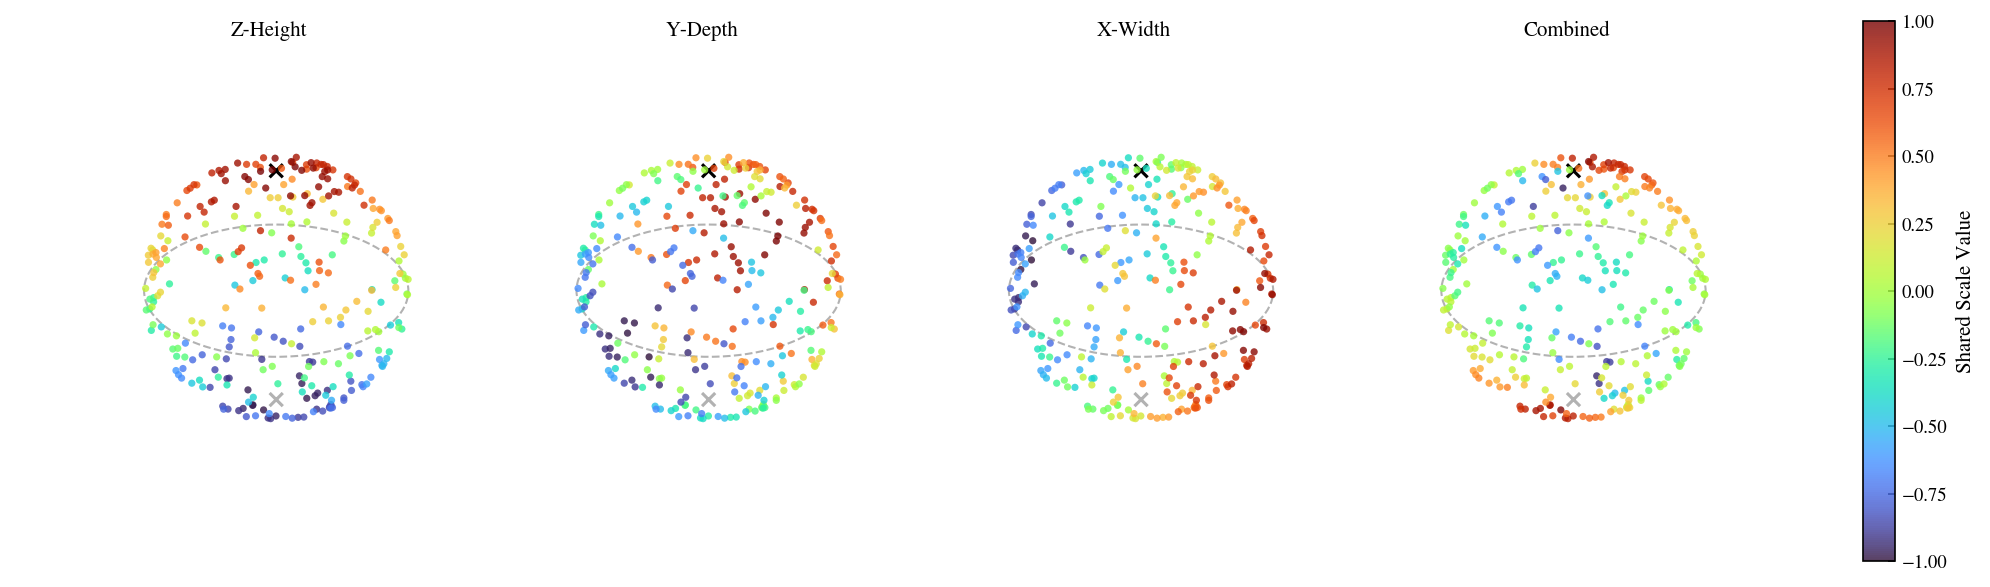

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate random spherical coordinates
n_points = 300
np.random.seed(42)

theta_pts = np.random.uniform(0, 2 * np.pi, n_points)
phi_pts = np.arccos(np.random.uniform(-1, 1, n_points))

# Convert to Cartesian (x, y, z)
x = np.sin(phi_pts) * np.cos(theta_pts)
y = np.sin(phi_pts) * np.sin(theta_pts)
z = np.cos(phi_pts)

# 2. Generate line coordinates for the Equator (Z = 0)
eq_theta = np.linspace(0, 2 * np.pi, 100)
eq_x = np.cos(eq_theta)
eq_y = np.sin(eq_theta)
eq_z = np.zeros_like(eq_theta)

# Data for 4 subplots
color_data = [
    {"values": z, "title": "Z-Height"},
    {"values": y, "title": "Y-Depth"},
    {"values": x, "title": "X-Width"},
    {"values": np.sin(theta_pts) * np.cos(phi_pts), "title": "Combined"},
]

vmin, vmax = -1.0, 1.0

# 3. Initialize a 1x4 grid of 3D subplots (removed layout='constrained' for manual spacing)
fig, axes = plt.subplots(
    1, 4, figsize=(14, 4.5), subplot_kw={"projection": "3d"}
)

# Reduce the horizontal spacing between subplots
fig.subplots_adjust(left=0.02, right=0.88, wspace=-0.15)

# 4. Loop through axes and plot
for ax, data in zip(axes, color_data):
    # Hint 1: Plot Equator line
    ax.plot(eq_x, eq_y, eq_z, color="gray", linestyle="--", linewidth=1, alpha=0.6, zorder=1)
    
    # Hint 2: Plot Poles (North:, South: [0,0,-1])
    ax.scatter([0, 0], [0, 0], [1, -1], color="black", marker="x", s=40, linewidths=1.5, zorder=3)

    # Plot the scatter points
    scatter = ax.scatter(
        x, y, z,
        c=data["values"],
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        s=12,
        edgecolor="none",
        alpha=0.8,
        zorder=2
    )
    
    ax.set_title(data["title"], pad=-10)
    ax.set_box_aspect([1,1,1])
    #ax.plot_surface(x, y, z, color='gray', alpha=0.1, edgecolor=None, linewidth=0.5)
    ax.axis("off")

# 5. Create a single colorbar pinned to the right edge
cbar_ax = fig.add_axes([0.90, 0.1, 0.015, 0.8]) # [left, bottom, width, height]
fig.colorbar(scatter, cax=cbar_ax, label="Shared Scale Value")
#fig.subplots_adjust(left=0.01, right=0.89, bottom=0.1, top=0.9, wspace=-0.55)

plt.show()


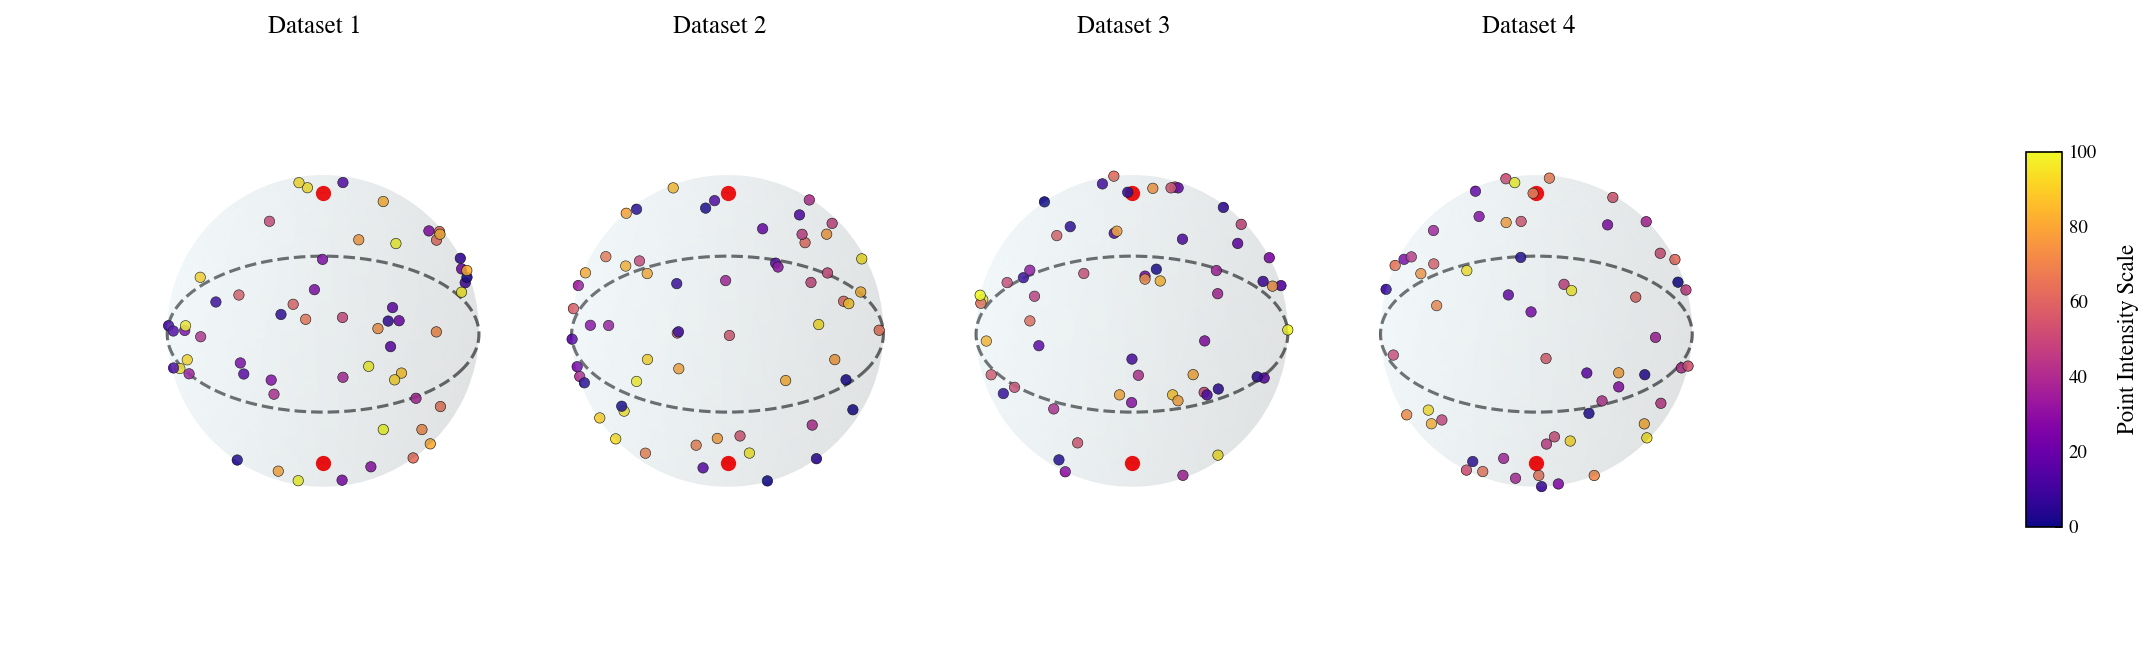

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# 1. Setup the figure and 1x4 3D subplots
fig, axes = plt.subplots(1, 4, subplot_kw={'projection': '3d'}, figsize=(16, 5))

# 2. Define the base geometry for a unit sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

# 3. Define the equator line
theta = np.linspace(0, 2 * np.pi, 200)
x_equator = np.cos(theta)
y_equator = np.sin(theta)
z_equator = np.zeros_like(theta)

# 4. Global colorbar normalization
vmin, vmax = 0, 100
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

# 5. Plot on each axis
for i, ax in enumerate(axes):
    # Highly transparent sphere
    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='lightblue', 
                    alpha=0.08, edgecolor='none')
    
    # Equator line
    ax.plot(x_equator, y_equator, z_equator, color='black', 
            linestyle='--', linewidth=1.5, alpha=0.6, label='Equator' if i==0 else "")
    
    # Poles
    ax.scatter([0, 0], [0, 0], [1, -1], color='red', s=40, 
               marker='o', depthshade=False, label='Poles' if i==0 else "")
    
    # Random points on surface
    num_points = 60
    z_pts = np.random.uniform(-1, 1, num_points)
    phi_pts = np.random.uniform(0, 2 * np.pi, num_points)
    r_xy = np.sqrt(1 - z_pts**2)
    x_pts = r_xy * np.cos(phi_pts)
    y_pts = r_xy * np.sin(phi_pts)
    
    point_values = np.random.uniform(vmin, vmax, num_points)
    
    ax.scatter(x_pts, y_pts, z_pts, c=point_values, cmap=cmap, 
               norm=norm, s=25, alpha=0.9, edgecolors='black', linewidths=0.3)
    
    ax.set_box_aspect([1, 1, 1])
    ax.set_title(f"Dataset {i+1}", fontsize=12, pad=0) # reduced pad to keep title close
    ax.set_axis_off()
    ax.patch.set_visible(False)

# 6. FIXED: Explicit positioning for the colorbar on the absolute right edge
# Format: [left_position, bottom_position, width, height] as fractions of the figure
cbar_ax = fig.add_axes([0.91, 0.25, 0.015, 0.5]) 
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Point Intensity Scale', fontsize=11, labelpad=10)

# 7. FIXED: Explicit subplot spacing layout instead of tight_layout()
# right=0.89 stops the subplots right before the colorbar starts at 0.91
# wspace=-0.12 uses negative spacing to force the invisible 3D borders to overlap
fig.subplots_adjust(left=0.01, right=0.89, bottom=0.1, top=0.9, wspace=-0.55)

plt.show()

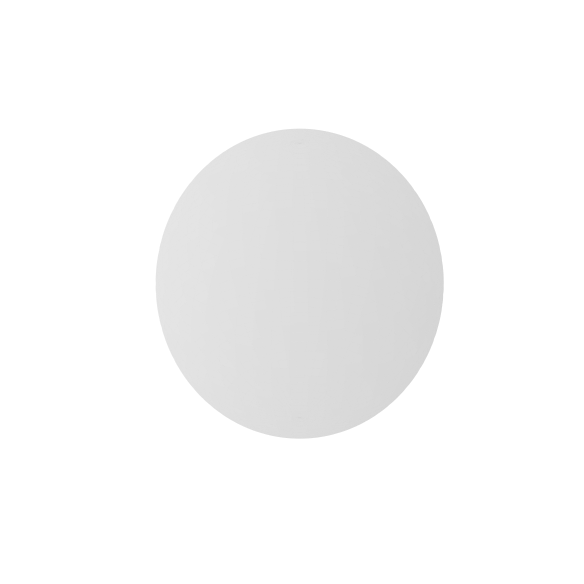

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sphere coordinates
u = np.linspace(0, 2 * np.pi, 300)
v = np.linspace(0, np.pi, 300)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Create 3D figure
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Plot with alpha (transparency) and edgecolors for better mesh visibility
ax.plot_surface(x, y, z, color='gray', alpha=0.1, edgecolor=None, linewidth=0.5)

# Set axes scale to equal so the sphere isn't distorted
ax.set_box_aspect([1, 1, 1])
#ax.axis('off')

plt.show()
